<a href="https://colab.research.google.com/github/Deepaksoni-dot/Deepaksoni-dot/blob/DeepLearning/NeuralNetworkOnMNISTdigits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Problem Statement:
 This assignment challenges students to construct and train a neural network to
 accurately classify handwritten digits from the MNIST dataset. The goal is to
 navigate through the preprocessing of image data, select an appropriate neural
 network architecture, and apply optimization techniques to achieve high
 classification accuracy.
####Introduction:

 The MNIST dataset is a large database of handwritten digits commonly used for
 training various image processing systems. The dataset contains 60,000 training
 images and 10,000 testing images, each of which is a 28x28 pixel grayscale
 image. The goal is to build a neural network model that can accurately classify
 these images into one of the ten digit classes (0 through 9).
 Objectives:
####Data Preprocessing:
Prepare the MNIST dataset for training and testing the
 neural network model. This includes normalization of image pixel values and
 converting the output labels to a one-hot encoded format.
####Model Development:
Create a neural network model capable of classifying
 28x28 pixel grayscale images of handwritten digits. The model should have an
 input layer, one or more hidden layers, and an output layer.
####Training:
Train the neural network model using the preprocessed training data.
 Utilize categorical cross-entropy as the loss function, stochastic gradient descent
 as the optimizer, and track accuracy as a performance metric.
####Evaluation:
Evaluate the performance of the trained model using the testing
 dataset, ensuring that the model generalizes well to unseen data.
####Prediction: Implement functionality to make predictions on single images or
 batches of images, returning the digit class with the highest probability.
####Analysis: Analyze the results, understand the model's performance, and explore
 ways to improve it if necessary.

In [ ]:
 from sklearn.datasets import fetch_openml
 mnist = fetch_openml('mnist_784', version=1)
 mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [ ]:
mnist["DESCR"]

"**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  \n**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  \n**Please cite**:  \n\nThe MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  \n\nIt is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 

In [ ]:
mnist["target"].value_counts()

,count
class,
1,7877
7,7293
3,7141
2,6990
9,6958
0,6903
6,6876
8,6825
4,6824


In [ ]:
import tensorflow.keras as keras

In [ ]:
import numpy as np
X = mnist['data'].copy()
y= mnist['target'].copy()
X = X.to_numpy()
y=y.to_numpy()

In [ ]:
X = X / 255.0  # scaling values between 0-1

In [ ]:
y[:5]

array(['5', '0', '4', '1', '9'], dtype=object)

In [ ]:
y=y.astype(np.int32)

In [ ]:
y=keras.utils.to_categorical(y)

In [ ]:
y[:3]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [ ]:
x_train=X[:55000]
y_train=y[:55000]
x_valid=X[55000:60000]
y_valid=y[55000:60000]
x_test=X[60000:]
y_test=y[60000:]

In [ ]:
x_train.shape,x_valid.shape,x_test.shape

((55000, 784), (5000, 784), (10000, 784))

In [ ]:
model=keras.models.Sequential()
model.add(keras.layers.Dense(784,activation="relu",input_shape=(784,)))
model.add(keras.layers.Dense(400,activation="relu"))
model.add(keras.layers.Dense(100,activation="relu"))
model.add(keras.layers.Dense(10,activation='softmax'))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 784)                 │         615,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 400)                 │         314,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          40,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 970,550 (3.70 MB)

 Trainable params: 970,550 (3.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="categorical_crossentropy",
 optimizer="sgd",
 metrics=["accuracy"])

In [ ]:
history=model.fit(x_train,y_train,epochs=20,validation_data=(x_valid,y_valid))

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7610 - loss: 0.9472 - val_accuracy: 0.9468 - val_loss: 0.2065
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9260 - loss: 0.2580 - val_accuracy: 0.9590 - val_loss: 0.1573
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9457 - loss: 0.1894 - val_accuracy: 0.9666 - val_loss: 0.1298
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9559 - loss: 0.1537 - val_accuracy: 0.9698 - val_loss: 0.1182
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9637 - loss: 0.1258 - val_accuracy: 0.9740 - val_loss: 0.0979
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9704 - loss: 0.1044 - val_accuracy: 0.9722 - val_loss: 0.1021
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9739 - loss: 0.0908 - val_accuracy: 0.9786 - val_loss: 0.0839
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9774 - loss: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

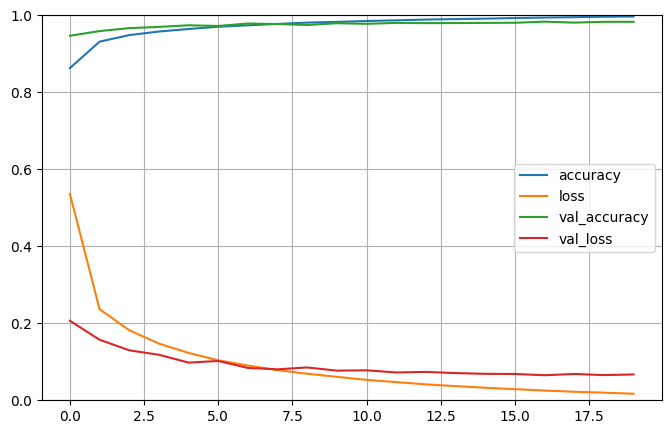

In [ ]:
 pd.DataFrame(history.history).plot(figsize=(8, 5))
 plt.grid(True)
 plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
 plt.show()

In [ ]:
model.evaluate(x_test,y_test)   #model evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9772 - loss: 0.0779


[0.06499460339546204, 0.9804999828338623]

In [ ]:
y_pred=model.predict(x_test[0:5])   #model prediction
y_pred.round(1)
y_pred=np.argmax(y_pred,axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


array([7, 2, 1, 0, 4])

In [ ]:
y_act=np.argmax(y_test[:5],axis=1)   #Actual output
y_act

array([7, 2, 1, 0, 4])

In [ ]:
model.save("MNIST_data.h5")

In [ ]:
#checkpoint_cb=keras.callbacks.ModelCheckpoint("/content/MNIST_data.h5",save_best_only=True)  for checkpoints at each epochs
Early_stopping_cb=keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)  # for saving best weights when performance is stagnant

In [ ]:
further_history = model.fit(x_train, y_train, epochs=7,validation_data=(x_valid, y_valid),callbacks=[Early_stopping_cb])

Epoch 1/7
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9972 - loss: 0.0158 - val_accuracy: 0.9820 - val_loss: 0.0692
Epoch 2/7
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9976 - loss: 0.0141 - val_accuracy: 0.9832 - val_loss: 0.0657
Epoch 3/7
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9986 - loss: 0.0119 - val_accuracy: 0.9820 - val_loss: 0.0688
Epoch 4/7
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9986 - loss: 0.0104 - val_accuracy: 0.9818 - val_loss: 0.0687
Epoch 5/7
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9987 - loss: 0.0099 - val_accuracy: 0.9826 - val_loss: 0.0669


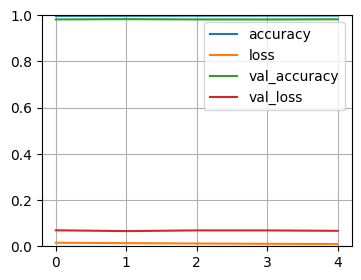

In [ ]:
pd.DataFrame(further_history.history).plot(figsize=(4,3))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9778 - loss: 0.0764


[0.06320715695619583, 0.9812999963760376]

There is no further increase in accuracy during evaluation after further increasing in epochs ie from 97.72 to 97.78 %

So far model is very well to predict the label of image.

In [ ]:
x_test.shape

(10000, 784)

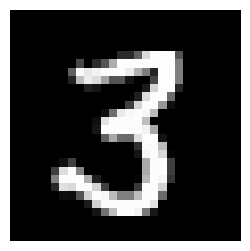

Image of Digit is : 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction by NN is : [3]


In [ ]:
i=np.random.randint(1,10000)
plt.figure(figsize=(3,3))
plt.gca().set_axis_off()
plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
plt.show()
print(f"Image of Digit is : {np.argmax(y_test[i])}")
Y=np.argmax(model.predict(x_test[i:i+1]),axis=1)
print(f"Prediction by NN is : {Y}")